In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab \Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning/

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning


Imports

In [ ]:
#!pip install umap

ERROR: Could not find a version that satisfies the requirement umap (from versions: none)
ERROR: No matching distribution found for umap


In [3]:
import os
import numpy as np
import pandas as pd

import tifffile as tiff
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision.models import resnet18
from sklearn.manifold import TSNE
#import umap

from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 44.3 MB/s eta 0:00:00


In [4]:
import timm

Paths & Metadata

In [5]:
DATA_DIR = "data/raw"
RESULTS_DIR = "results/figures"
PROCESSED_DIR = "data/processed"
os.makedirs(RESULTS_DIR, exist_ok=True)


In [6]:
X = np.load("data/splits/X_images.npy")
y = np.load("data/splits/y_labels.npy")

print(X.shape)
print(y.shape)

(3845, 3, 128, 128)
(3845, 3)


Dataset + Augmentation

In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np

class MicroscopySSLDataset(Dataset):

    def __init__(self, X):
        """
        X: numpy array of shape
           (N, C, H, W) OR (N, H, W, C)
           values expected in [0,1]
        """
        self.X = X

    def __len__(self):
        return len(self.X)

    def augment(self, x):

      x = x.copy().astype(np.float32)

      # flips
      if np.random.rand() < 0.5:
          x = np.flip(x, axis=2)

      if np.random.rand() < 0.5:
          x = np.flip(x, axis=1)

      # ✅ FIX: noise must be float32
      if np.random.rand() < 0.3:
          noise = np.random.normal(0, 0.01, x.shape).astype(np.float32)
          x = x + noise

      # intensity scaling
      if np.random.rand() < 0.5:
          scale = np.float32(np.random.uniform(0.9, 1.1))
          x = x * scale

      # channel dropout
      if np.random.rand() < 0.2:
          ch = np.random.randint(0, x.shape[0])
          x[ch] = 0

      x = np.clip(x, 0, 1).astype(np.float32)

      return x

    def __getitem__(self, idx):

        img = self.X[idx]

        # ---- fix shape: HWC → CHW ----
        if img.ndim == 3 and img.shape[-1] in [3, 5]:
            img = np.transpose(img, (2, 0, 1))

        # ---- ensure float32 ----
        img = img.astype(np.float32)

        # ---- generate two views ----
        x1 = self.augment(img)
        x2 = self.augment(img)

        # ---- convert to tensor ----
        x1 = torch.from_numpy(x1).float()
        x2 = torch.from_numpy(x2).float()

        # ---- normalize for ViT ----
        x1 = (x1 - 0.5) / 0.5
        x2 = (x2 - 0.5) / 0.5

        return x1, x2

In [ ]:
dataset = MicroscopySSLDataset(X)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)

x1, x2 = next(iter(dataloader))

print(x1.shape)   # (B, C, H, W)
print(x1.min(), x1.max())  # should be roughly [-1, 1]

torch.Size([64, 3, 128, 128])
tensor(-1.) tensor(1.)


In [ ]:
print(x1.dtype)   # MUST be torch.float32
print(x1.min(), x1.max())

torch.float32
tensor(-1.) tensor(1.)


Vision Transformer Backbone

In [ ]:
import torchvision.models as models
import torch.nn as nn

class Encoder(nn.Module):

    def __init__(self, embedding_dim=256):
        super().__init__()

        backbone = models.resnet18(weights="IMAGENET1K_V1")
        backbone.conv1 = nn.Conv2d(
            3, 64, kernel_size=7, stride=2, padding=3, bias=False
        )  # adjust if needed for channels

        backbone.fc = nn.Identity()   # remove classifier

        self.backbone = backbone
        self.fc = nn.Linear(512, embedding_dim)

    def forward(self, x):
        x = self.backbone(x)
        z = self.fc(x)
        return z

Projection Head

In [ ]:
class SimCLR(nn.Module):

    def __init__(self, embedding_dim=256):

        super().__init__()

        self.encoder = Encoder(embedding_dim)

        self.projector = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, 128)
        )

    def forward(self, x):

        z = self.encoder(x)
        p = self.projector(z)

        return z, p

NT-Xent Loss + Cosine Similarity

In [ ]:
def nt_xent_loss(p1, p2, temperature=0.2):

    B = p1.size(0)

    p1 = F.normalize(p1, dim=1)
    p2 = F.normalize(p2, dim=1)

    z = torch.cat([p1, p2], dim=0)

    sim = torch.matmul(z, z.T) / temperature

    mask = torch.eye(2*B, device=z.device).bool()
    sim = sim.masked_fill(mask, -9e15)

    targets = torch.arange(B, device=z.device)
    targets = torch.cat([targets+B, targets])

    loss = F.cross_entropy(sim, targets)

    return loss, sim, targets

Accuracy Metrics

In [ ]:
def contrastive_accuracy(sim, targets):

    ranks = sim.argsort(dim=1, descending=True)

    pos = (ranks == targets.unsqueeze(1)).nonzero()

    pos_rank = pos[:,1]

    top1 = (pos_rank == 0).float().mean()
    top5 = (pos_rank < 5).float().mean()
    mean_rank = pos_rank.float().mean()

    return top1.item(), top5.item(), mean_rank.item()

Cosine Learning Rate Schedule with Warmup

In [ ]:
class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):

    def __init__(self, optimizer, warmup_epochs, max_epochs, min_lr=1e-6, last_epoch=-1):

        self.warmup_epochs = warmup_epochs
        self.max_epochs = max_epochs
        self.min_lr = min_lr

        super().__init__(optimizer, last_epoch)

    def get_lr(self):

        if self.last_epoch < self.warmup_epochs:

            return [
                base_lr * (self.last_epoch+1) / self.warmup_epochs
                for base_lr in self.base_lrs
            ]

        progress = (self.last_epoch - self.warmup_epochs) / (self.max_epochs - self.warmup_epochs)

        cosine_decay = 0.5 * (1 + np.cos(np.pi * progress))

        return [
            self.min_lr + (base_lr - self.min_lr) * cosine_decay
            for base_lr in self.base_lrs
        ]

Training Setup

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SimCLR().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = WarmupCosineScheduler(
    optimizer,
    warmup_epochs=20,
    max_epochs=200
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 209MB/s]


Training Loop

In [ ]:
num_epochs = 200

losses = []
top1_list = []
top5_list = []

for epoch in range(num_epochs):

    model.train()

    total_loss = 0
    total_top1 = 0
    total_top5 = 0

    loop = tqdm(dataloader)

    for x1, x2 in loop:

        x1 = x1.to(device)
        x2 = x2.to(device)

        z1, p1 = model(x1)
        z2, p2 = model(x2)

        loss, sim, targets = nt_xent_loss(p1, p2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        top1, top5, mean_rank = contrastive_accuracy(sim, targets)

        total_loss += loss.item()
        total_top1 += top1
        total_top5 += top5

        loop.set_postfix(
            loss=loss.item(),
            top1=top1,
            top5=top5
        )

    scheduler.step()

    # ✅ compute epoch metrics
    epoch_loss = total_loss / len(dataloader)
    epoch_top1 = total_top1 / len(dataloader)
    epoch_top5 = total_top5 / len(dataloader)

    # ✅ store them
    losses.append(epoch_loss)
    top1_list.append(epoch_top1)
    top5_list.append(epoch_top5)

    print(
        f"Epoch {epoch+1} | "
        f"Loss {epoch_loss:.3f} | "
        f"Top1 {epoch_top1:.3f} | "
        f"Top5 {epoch_top5:.3f}"
    )

100%|██████████| 60/60 [00:12<00:00,  4.75it/s, loss=2.14, top1=0.688, top5=0.922]


Epoch 1 | Loss 2.878 | Top1 0.525 | Top5 0.734


100%|██████████| 60/60 [00:12<00:00,  4.78it/s, loss=1.71, top1=0.828, top5=0.969]


Epoch 2 | Loss 1.806 | Top1 0.836 | Top5 0.957


100%|██████████| 60/60 [00:12<00:00,  4.79it/s, loss=1.18, top1=0.977, top5=0.992]


...

Epoch 198 | Loss 0.654 | Top1 1.000 | Top5 1.000


100%|██████████| 60/60 [00:12<00:00,  4.80it/s, loss=0.645, top1=1, top5=1]


Epoch 199 | Loss 0.655 | Top1 1.000 | Top5 1.000


100%|██████████| 60/60 [00:12<00:00,  4.71it/s, loss=0.656, top1=1, top5=1]

Epoch 200 | Loss 0.656 | Top1 1.000 | Top5 1.000


Plot Loss Curve

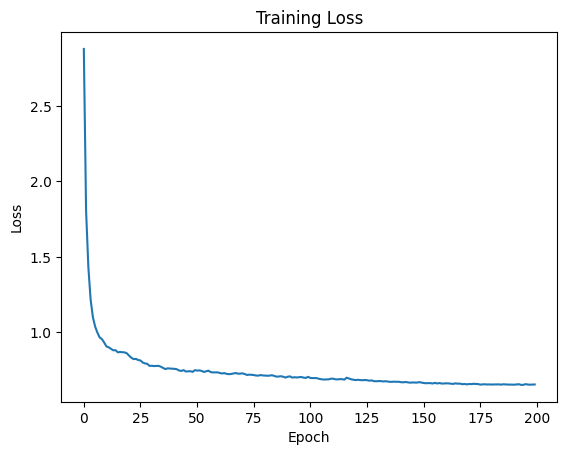

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

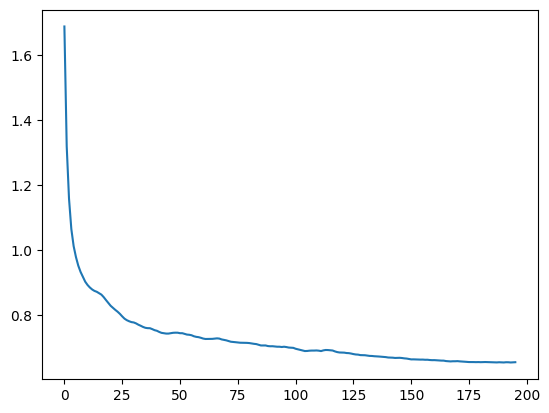

In [ ]:
def smooth(x, k=5):
    return np.convolve(x, np.ones(k)/k, mode='valid')

plt.plot(smooth(losses))

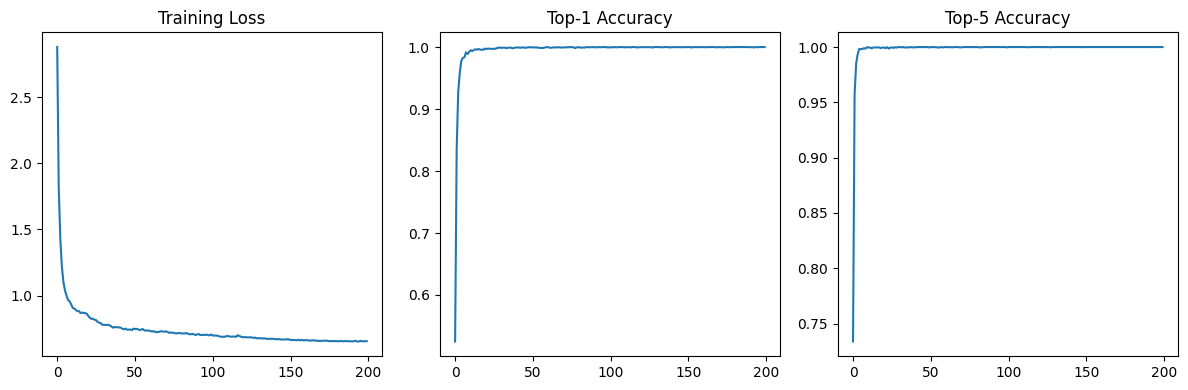

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,3,1)
plt.plot(losses)
plt.title("Training Loss")

# Top1
plt.subplot(1,3,2)
plt.plot(top1_list)
plt.title("Top-1 Accuracy")

# Top5
plt.subplot(1,3,3)
plt.plot(top5_list)
plt.title("Top-5 Accuracy")

plt.tight_layout()
plt.show()

Extract embeddings

In [ ]:
def extract_embeddings(model, X):

    model.eval()
    embeddings = []

    with torch.no_grad():

        for i in range(0, len(X), 64):

            batch = X[i:i+64]

            if batch.shape[-1] == 3:
                batch = np.transpose(batch, (0,3,1,2))

            batch = torch.tensor(batch, dtype=torch.float32).to(device)
            batch = (batch - 0.5) / 0.5

            z, _ = model(batch)

            embeddings.append(z.cpu().numpy())

    return np.concatenate(embeddings)

In [ ]:
embeddings = extract_embeddings(model, X)
print(embeddings.shape)

(3845, 256)


In [7]:
moa = y[:,0]
compound = y[:, 1]
concentration = y[:, 2]

In [27]:
replicate_groups = np.array([
    f"{c}_{d}" for c, d in zip(compound, concentration)
])

In [ ]:
ssl_df = pd.DataFrame(embeddings, columns=[f"PC{i}" for i in range(1, embeddings.shape[1] + 1)])
ssl_df["moa"] = moa
ssl_df["compound"] = compound
ssl_df["concentration"] = concentration

ssl_df.to_csv("ssl_resnet_weighted_embeddings.csv", index=False)

In [8]:
ssl_df = pd.read_csv("data/processed/ssl_resnet_weighted_embeddings.csv")

print(ssl_df.shape)

(3845, 259)


UMAP Visualization

In [9]:
le = LabelEncoder()
y_encoded = le.fit_transform(moa)

In [11]:
X_embeddings = ssl_df.drop(columns=["moa", "compound", "concentration"]).values

In [12]:
from sklearn.preprocessing import normalize
X_embeddings = normalize(X_embeddings)

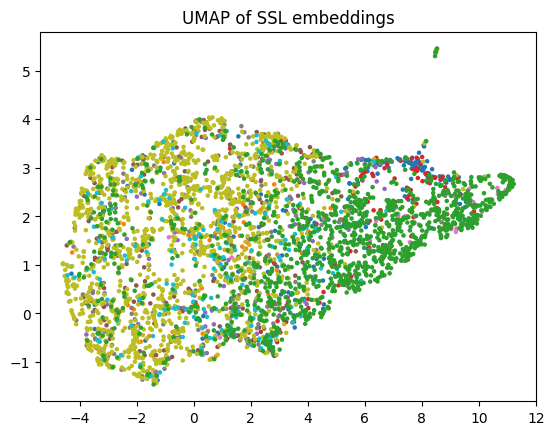

In [13]:
import umap

reducer = umap.UMAP(n_components=2)
emb_2d = reducer.fit_transform(X_embeddings)

plt.scatter(emb_2d[:,0], emb_2d[:,1], c=y_encoded, cmap="tab10", s=5)
plt.title("UMAP of SSL embeddings")
plt.savefig(os.path.join(RESULTS_DIR, "UMAP of SimCLR with weighted RESNET embeddings.png"), dpi=300, bbox_inches="tight")
plt.show()

MOA prediction (kNN)

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

k_values = range(1, 31)

results = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(knn, X_embeddings, y_encoded, cv=5)

    mean_score = scores.mean()

    results.append(mean_score)

    print(f"k = {k}, accuracy = {mean_score:.4f}")

k = 1, accuracy = 0.4892
k = 2, accuracy = 0.4861
k = 3, accuracy = 0.5316
k = 4, accuracy = 0.5602
k = 5, accuracy = 0.5732
k = 6, accuracy = 0.5875
k = 7, accuracy = 0.5992
k = 8, accuracy = 0.6042
k = 9, accuracy = 0.6086
k = 10, accuracy = 0.6083
k = 11, accuracy = 0.6091
k = 12, accuracy = 0.6133
k = 13, accuracy = 0.6120
k = 14, accuracy = 0.6172
k = 15, accuracy = 0.6205
k = 16, accuracy = 0.6229
k = 17, accuracy = 0.6229
k = 18, accuracy = 0.6195
k = 19, accuracy = 0.6192
k = 20, accuracy = 0.6224
k = 21, accuracy = 0.6213
k = 22, accuracy = 0.6213
k = 23, accuracy = 0.6244
k = 24, accuracy = 0.6263
k = 25, accuracy = 0.6252
k = 26, accuracy = 0.6242
k = 27, accuracy = 0.6257
k = 28, accuracy = 0.6252
k = 29, accuracy = 0.6250
k = 30, accuracy = 0.6265


In [15]:
best_k = k_values[np.argmax(results)]
best_score = max(results)

print("Best k:", best_k)
print("Best accuracy:", best_score)

Best k: 30
Best accuracy: 0.6265279583875163


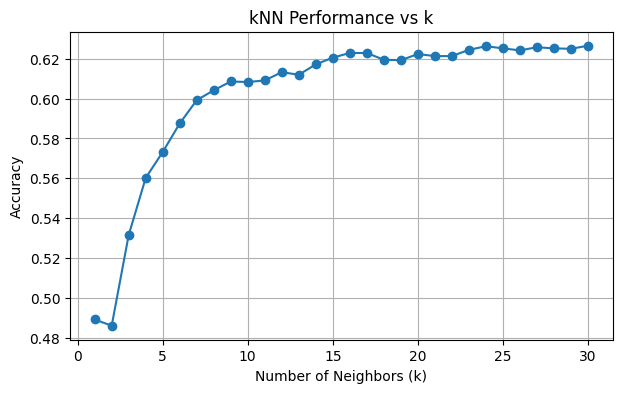

In [16]:
plt.figure(figsize=(7,4))

plt.plot(k_values, results, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("kNN Performance vs k")

plt.grid(True)
plt.savefig(os.path.join(RESULTS_DIR, "SimCLR with weighted RESNET kNN Performance vs k in MOA prediction.png"), dpi=300, bbox_inches="tight")

plt.show()

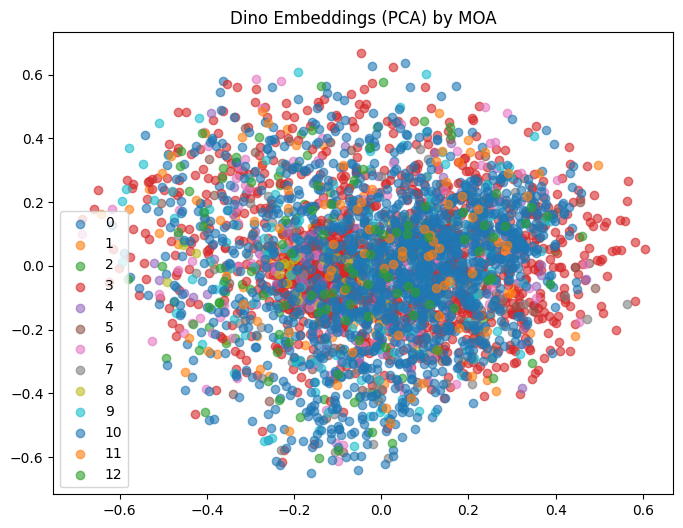

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(X_embeddings)

plt.figure(figsize=(8,6))

for moa in np.unique(y_encoded):
    idx = y_encoded == moa
    plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1], label=str(moa), alpha=0.6)

plt.legend()
plt.title("Dino Embeddings (PCA) by MOA")
plt.savefig(os.path.join(RESULTS_DIR, "SimCLR with weighted RESNET Embeddings (PCA) by MOA.png"), dpi=300, bbox_inches="tight")
plt.show()

LOCO (Leave-One-Compound-Out)

In [18]:
compound_ids = y[:,1]
compound_enc = LabelEncoder().fit_transform(compound)

In [19]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

logo = LeaveOneGroupOut()

k_values = range(1, 31)   # test k from 1 to 30
k_scores = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")

    scores = []

    for train_idx, test_idx in logo.split(X_embeddings, y_encoded, groups=compound_ids):

        X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
        y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

        knn.fit(X_train, y_train)

        acc = knn.score(X_test, y_test)

        scores.append(acc)

    mean_score = np.mean(scores)
    k_scores.append(mean_score)

    print(f"k = {k}, LOCO accuracy = {mean_score:.4f}")

k = 1, LOCO accuracy = 0.1127
k = 2, LOCO accuracy = 0.1022
k = 3, LOCO accuracy = 0.0944
k = 4, LOCO accuracy = 0.0887
k = 5, LOCO accuracy = 0.0823
k = 6, LOCO accuracy = 0.0803
k = 7, LOCO accuracy = 0.0709
k = 8, LOCO accuracy = 0.0717
k = 9, LOCO accuracy = 0.0709
k = 10, LOCO accuracy = 0.0740
k = 11, LOCO accuracy = 0.0694
k = 12, LOCO accuracy = 0.0699
k = 13, LOCO accuracy = 0.0669
k = 14, LOCO accuracy = 0.0655
k = 15, LOCO accuracy = 0.0654
k = 16, LOCO accuracy = 0.0668
k = 17, LOCO accuracy = 0.0663
k = 18, LOCO accuracy = 0.0667
k = 19, LOCO accuracy = 0.0663
k = 20, LOCO accuracy = 0.0677
k = 21, LOCO accuracy = 0.0691
k = 22, LOCO accuracy = 0.0706
k = 23, LOCO accuracy = 0.0712
k = 24, LOCO accuracy = 0.0719
k = 25, LOCO accuracy = 0.0709
k = 26, LOCO accuracy = 0.0698
k = 27, LOCO accuracy = 0.0694
k = 28, LOCO accuracy = 0.0680
k = 29, LOCO accuracy = 0.0680
k = 30, LOCO accuracy = 0.0691


In [21]:
best_k = k_values[np.argmax(k_scores)]
best_score = max(k_scores)

print("Best k:", best_k)
print("Best LOCO accuracy:", best_score)

Best k: 1
Best LOCO accuracy: 0.11265787058469985


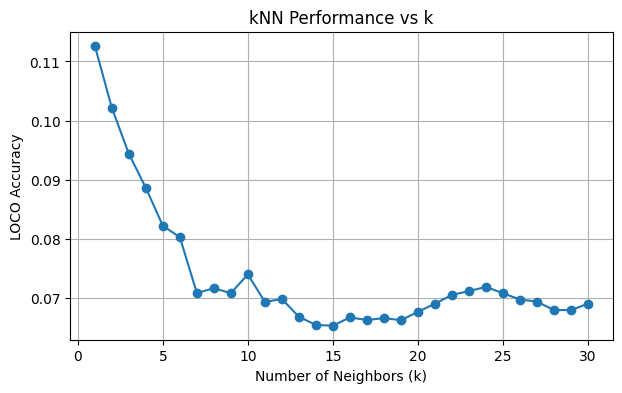

In [20]:
plt.figure(figsize=(7,4))

plt.plot(k_values, k_scores, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("LOCO Accuracy")
plt.title("kNN Performance vs k")
plt.savefig(os.path.join(RESULTS_DIR, "SimCLR with weighted RESNET LOCO kNN Performance vs k"), dpi=300, bbox_inches="tight")
plt.grid(True)

plt.show()

In [22]:
compound_names = y[:,1]
compound_ids = LabelEncoder().fit_transform(compound_names)

In [23]:
le_comp = LabelEncoder()
compound_encoded = le_comp.fit_transform(compound_ids)

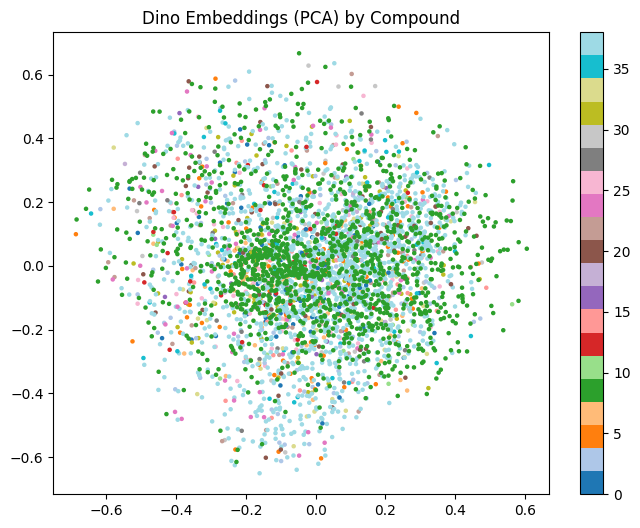

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    emb_2d[:,0],
    emb_2d[:,1],
    c=compound_encoded,   # ✅ numeric now
    cmap="tab20",
    s=5
)

plt.title("Dino Embeddings (PCA) by Compound")
plt.savefig(os.path.join(RESULTS_DIR, "SimCLR with weighted RESNET Embeddings (PCA) by Compound"), dpi=300, bbox_inches="tight")
plt.colorbar()
plt.show()

Replicate prediction

In [25]:
from sklearn.metrics.pairwise import cosine_similarity
def percent_replicating(embeddings, replicate_groups):

    sim = cosine_similarity(embeddings)

    replicate_scores = []
    null_scores = []

    n = len(replicate_groups)

    for i in range(n):
        for j in range(i+1, n):

            if replicate_groups[i] == replicate_groups[j]:
                replicate_scores.append(sim[i, j])
            else:
                null_scores.append(sim[i, j])

    threshold = np.percentile(null_scores, 95)

    replicating = np.sum(np.array(replicate_scores) > threshold)

    percent = replicating / len(replicate_scores)

    return percent

In [28]:
weightedRESNET_rep = percent_replicating(X_embeddings, replicate_groups)


print("PCA percent replicating:", weightedRESNET_rep)

PCA percent replicating: 0.0902423581753968
